![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [1]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
%matplotlib inline

In [4]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [5]:
df.shape

(541462, 3)

<Axes: >

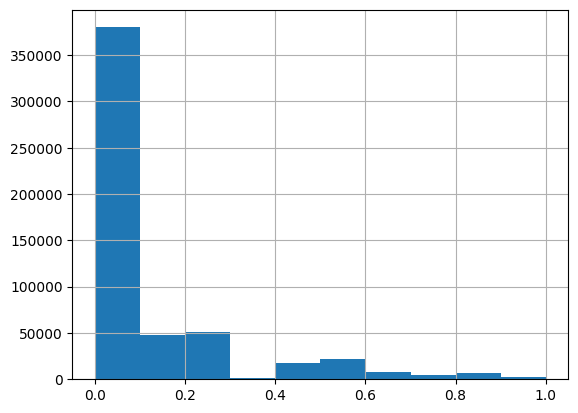

In [6]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [7]:
# Separación de variable de interés (y)
y = df.target
y.describe()

,target
count,541462.000000
mean,0.102991
std,0.196979
min,0.000000
25%,0.000000
50%,0.000000
75%,0.166667
max,1.000000


In [8]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [9]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [17]:
# Celda 1
from sklearn.linear_model import LinearRegression

# Creación de matrices de documentos usando CountVectorizer a partir de X
vect = CountVectorizer()
X_train_dtm = vect.fit_transform(X_train) #Ajustar en train
X_test_dtm = vect.transform(X_test) #Transformar en test

# Visualización de diccionario de palabras con su respectivo ID asignado
print(list(vect.vocabulary_.items())[:10])

# Impresión de dimensiones de matriz de documentos donde las filas son documentos y las columnas son términos o tokens
print(X_test_dtm.shape)

# Visualización de 50 términos en el diccionario de palabras
print(vect.get_feature_names_out()[-150:-100])

# Modelo
model = LinearRegression()
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

# MSE
mse_1 = metrics.mean_squared_error(y_test, y_pred)

print("MSE CountVectorizer:", mse_1)


[('oral', 91127), ('history', 60749), ('is', 67439), ('what', 136457), ('ever', 46583), ('they', 125107), ('say', 110750), ('it', 67682), ('nazis', 86202), ('in', 64454)]
(178683, 141176)
['𝗕𝗲' '𝗙𝗮𝘁𝗵𝗲𝗿' '𝗜𝗳' '𝗦𝗼' '𝗧𝗿𝘂𝗹𝘆' '𝗮𝗻𝗱' '𝗮𝗻𝗻𝗼𝘂𝗻𝗰𝗲' '𝗮𝘀' '𝗯𝗲' '𝗯𝗶𝗹𝗹𝗶𝗼𝗻' '𝗯𝘆'
 '𝗰𝗮𝗿𝗲𝗳𝘂𝗹' '𝗱𝗼' '𝗱𝗼𝗹𝗹𝗮𝗿𝘀' '𝗳𝗿𝗼𝗺' '𝗳𝗿𝗼𝗻𝘁' '𝗳𝘂𝗹𝗹' '𝗴𝗞𝗭𝗘𝗳𝗿𝗪𝟱𝗺𝟳𝗤' '𝗴𝗶𝘃𝗲'
 '𝗵𝗮𝘃𝗲' '𝗵𝗲𝗮𝘃𝗲𝗻' '𝗵𝗼𝗻𝗼𝗿𝗲𝗱' '𝗵𝘁𝘁𝗽𝘀' '𝗵𝘆𝗽𝗼𝗰𝗿𝗶𝘁𝗲𝘀' '𝗶𝗻' '𝗶𝘁' '𝗻𝗲𝗲𝗱𝘆' '𝗻𝗼'
 '𝗻𝗼𝘁' '𝗼𝗳' '𝗼𝗻' '𝗼𝘁𝗵𝗲𝗿𝘀' '𝗽𝗿𝗮𝗰𝘁𝗶𝗰𝗲' '𝗿𝗲𝗰𝗲𝗶𝘃𝗲𝗱' '𝗿𝗲𝘄𝗮𝗿𝗱' '𝗿𝗶𝗴𝗵𝘁𝗲𝗼𝘂𝘀𝗻𝗲𝘀𝘀'
 '𝘀𝗲𝗲𝗻' '𝘀𝘁𝗿𝗲𝗲𝘁𝘀' '𝘀𝘆𝗻𝗮𝗴𝗼𝗴𝘂𝗲𝘀' '𝘁𝗲𝗹𝗹' '𝘁𝗵𝗲' '𝘁𝗵𝗲𝗶𝗿' '𝘁𝗵𝗲𝗺' '𝘁𝗵𝗲𝘆' '𝘁𝗼'
 '𝘁𝗿𝘂𝗺𝗽𝗲𝘁𝘀' '𝘄𝗵𝗲𝗻' '𝘄𝗶𝗹𝗹' '𝘄𝗶𝘁𝗵' '𝘆𝗼𝘂']
MSE Tokenización con CountVectorizer: 0.037211775285087866


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [ ]:
# Celda 2
# Creación de matrices de documentos usando CountVectorizer a partir de X y usando n-gramas
# a partir del parámetro 'ngram_range=(1, 3)'
vect = CountVectorizer(ngram_range=(1, 3))
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# Impresión dimensiones de matriz de documentos donde las filas son documentos y las columnas son términos o tokens
print(X_test_dtm.shape)

# Visualización de 50 términos en el diccionario de palabras
print(vect.get_feature_names_out()[-150:-100])

# Modelo
model = LinearRegression()
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

# MSE
mse_2 = metrics.mean_squared_error(y_test, y_pred)

print("MSE Trigramas:", mse_2)

(178683, 14221994)
['𝙛𝙖𝙢𝙞𝙡𝙞𝙚𝙨' '𝙛𝙖𝙢𝙞𝙡𝙞𝙚𝙨 𝙖𝙣𝙙' '𝙛𝙖𝙢𝙞𝙡𝙞𝙚𝙨 𝙖𝙣𝙙 𝙡𝙤𝙫𝙚𝙙' '𝙛𝙚𝙬' '𝙛𝙚𝙬 𝙙𝙖𝙮𝙨'
 '𝙛𝙚𝙬 𝙙𝙖𝙮𝙨 it' '𝙝𝙖𝙨' '𝙝𝙖𝙨 𝙗𝙚𝙚𝙣' '𝙝𝙖𝙨 𝙗𝙚𝙚𝙣 𝙚𝙭𝙩𝙚𝙣𝙙𝙚𝙙' '𝙞𝙣' '𝙞𝙣 𝙢𝙚𝙨𝙨𝙖𝙜𝙚'
 '𝙞𝙣 𝙢𝙚𝙨𝙨𝙖𝙜𝙚 𝙖𝙙𝙙𝙧𝙚𝙨𝙨𝙚𝙙' '𝙞𝙣 𝙩𝙝𝙚' '𝙞𝙣 𝙩𝙝𝙚 𝙥𝙖𝙨𝙩' '𝙞𝙣 𝙩𝙝𝙚 𝙬𝙖𝙩𝙚𝙧𝙨' '𝙠𝙚𝙚𝙥'
 '𝙠𝙚𝙚𝙥 my' '𝙠𝙚𝙚𝙥 my job' '𝙡𝙖' '𝙡𝙖 scalia' '𝙡𝙖 scalia if' '𝙡𝙤𝙫𝙚𝙙'
 '𝙡𝙤𝙫𝙚𝙙 𝙤𝙣𝙚𝙨' '𝙡𝙤𝙫𝙚𝙙 𝙤𝙣𝙚𝙨 𝙤𝙛' '𝙢𝙚𝙨𝙨𝙖𝙜𝙚' '𝙢𝙚𝙨𝙨𝙖𝙜𝙚 𝙖𝙙𝙙𝙧𝙚𝙨𝙨𝙚𝙙'
 '𝙢𝙚𝙨𝙨𝙖𝙜𝙚 𝙖𝙙𝙙𝙧𝙚𝙨𝙨𝙚𝙙 𝙩𝙤' '𝙢𝙤𝙩𝙝𝙚𝙧' '𝙢𝙤𝙩𝙝𝙚𝙧 𝙙𝙧𝙪𝙣𝙠' '𝙢𝙤𝙩𝙝𝙚𝙧 𝙙𝙧𝙪𝙣𝙠 𝙤𝙧' '𝙣𝙤'
 '𝙣𝙤 𝙈𝙤𝙨𝙡𝙚𝙢𝙨' '𝙣𝙤 𝙈𝙤𝙨𝙡𝙚𝙢𝙨 𝙪𝙣𝙩𝙞𝙡' '𝙣𝙤𝙩' '𝙣𝙤𝙩 𝙗𝙚' '𝙣𝙤𝙩 𝙗𝙚 𝙪𝙨𝙞𝙣𝙜' '𝙤𝙛'
 '𝙤𝙛 𝙩𝙝𝙚' '𝙤𝙛 𝙩𝙝𝙚 𝙥𝙚𝙧𝙨𝙤𝙣𝙣𝙚𝙡' '𝙤𝙛𝙛' '𝙤𝙛𝙛 𝙩𝙝𝙚' '𝙤𝙛𝙛 𝙩𝙝𝙚 𝙆𝙤𝙧𝙚𝙖𝙣' '𝙤𝙣'
 '𝙤𝙣 𝙗𝙤𝙖𝙧𝙙' '𝙤𝙣 𝙗𝙤𝙖𝙧𝙙 so' '𝙤𝙣𝙚𝙨' '𝙤𝙣𝙚𝙨 𝙤𝙛' '𝙤𝙣𝙚𝙨 𝙤𝙛 𝙩𝙝𝙚' '𝙤𝙣𝙡𝙮'
 '𝙤𝙣𝙡𝙮 𝙖𝙘𝙠𝙣𝙤𝙬𝙡𝙚𝙙𝙜𝙚𝙙']


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

###### #Celda 3
TfidfVectorizer convierte texto en una matriz numérica igual que CountVectorizer, pero asigna a cada término un peso TF-IDF, basándose en la importancia de cada palabra dentro del documento. Suele ser mejor cuando quieres resaltar términos discriminativos, por ejemplo en clasificación de textos, búsqueda o similitud entre documentos.

Funciona mediante dos componentes: TF (Term Frequency) que mide la frecuencia de una palabra en un documento. Es decir, cuántas veces aparece un término dentro de un texto específico y IDF (Inverse Document Frequency) que mide qué tan única o informativa es una palabra en el conjunto de documentos. Penaliza palabras que aparecen con mucha frecuencia en todos los textos (como artículos o palabras comunes) y da mayor peso a palabras más raras.

CountVectorizer solo produce conteos de cuantas veces aparece cada token en cada documento. Suele ser preferible cuando los conteos absolutos importan de verdad, o cuando vas a aplicar después de un modelo que ya maneja bien esas frecuencias.

En términos generales, TF-IDF pondera los términos basándose principalmente en su importancia dentro del documento, mientras que Count Vectorizer crea representaciones de frecuencia [1]

Ventajas:

* Reduce el peso de palabras muy frecuentes y poco informativas

* Mejora tareas donde importa la relevancia semántica más que la repetición

* Ayuda a comparar documentos de distinta longitud de forma más justa

Desventajas:
* Menos interpretable que contar palabras directamente;
puede penalizar términos realmente importantes si aparecen en muchos documentos;
añade una transformación adicional, así que ya no trabajas con frecuencias puras.

Ventajas:

Reduce la importancia de palabras muy comunes (como “the”, “and”, etc.).
Mejora la representación semántica del texto al destacar palabras más relevantes.
Suele mejorar el desempeño de los modelos en tareas de NLP.
Disminuye el ruido en los datos.

Desventajas:

Es más costoso computacionalmente que el conteo simple.
Puede eliminar información útil en algunos casos donde la frecuencia absoluta es importante.
No captura el orden ni el contexto de las palabras (igual que CountVectorizer).
Puede ser menos interpretable que el conteo directo.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [13]:
# Celda 4
# Creación de matrices de documentos usando TF-IDF a partir de X
vect = TfidfVectorizer()
X_train_dtm = vect.fit_transform(X_train)
X_test_dtm = vect.transform(X_test)

# Impresión dimensiones de matriz de documentos donde las filas son documentos y las columnas son términos o tokens
print(X_test_dtm.shape)

# Visualización de 50 términos en el diccionario de palabras
print(vect.get_feature_names_out()[-150:-100])

# Modelo
model = LinearRegression()
model.fit(X_train_dtm, y_train)
y_pred = model.predict(X_test_dtm)

# MSE
mse_4 = metrics.mean_squared_error(y_test, y_pred)

print("MSE TF-IDF:", mse_4)

## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

In [14]:
# Celda 5 Código para graficos y tablas comparativas
import matplotlib.pyplot as plt

# Tabla
resultados = {"CountVectorizer": mse_1,
              "CountVectorizer con Trigramas": mse_2,
              "TF-IDF": mse_4}

df_resultados = pd.DataFrame(list(resultados.items()), columns=["Modelo", "MSE"])

print(df_resultados)

#Gráfico
plt.figure()
plt.bar(df_resultados["Modelo"], df_resultados["MSE"])
plt.xlabel("Modelo")
plt.ylabel("MSE")
plt.title("Comparación de modelos de tokenización")
plt.xticks(rotation=30)
plt.show()

###### #Punto 5.1 - Comparación y análisis de resultados

Se compararon diferentes técnicas de tokenización para evaluar su impacto en el desempeño del modelo de regresión, utilizando como métrica el error cuadrático medio (MSE).

En primer lugar, el modelo basado en CountVectorizer mostró un desempeño base (MSE= 0.03721) al representar los textos únicamente mediante la frecuencia de palabras. Esta aproximación, aunque sencilla, no considera la relevancia de los términos dentro del corpus.

Posteriormente, al incorporar trigramas, se buscó capturar mayor contexto en los textos. Sin embargo, esta técnica incrementa significativamente la dimensionalidad del modelo, lo que puede generar sobreajuste y afectar negativamente el desempeño, dependiendo de los datos.

Finalmente, el uso de TF-IDF permitió ponderar la importancia de las palabras, reduciendo el peso de términos comunes y destacando aquellos más relevantes. Esto generalmente conduce a una mejor representación del texto y, en muchos casos, a un menor MSE.

En conclusión, el preprocesamiento de texto tiene un impacto significativo en el desempeño del modelo. Técnicas más avanzadas como TF-IDF tienden a mejorar los resultados al ofrecer representaciones más informativas, mientras que el uso de n-gramas puede ser útil pero debe manejarse con cuidado debido al aumento en la complejidad del modelo.

## Referencias

[1] Comparative Study among Term Frequency-Inverse Document Frequency and Count Vectorizer towards K Nearest Neighbor and Decision Tree Classifiers for Text Dataset https://doi.org/10.3126/njmr.v7i2.68189